# Medical Image Processing: Final Project
## Einar López Altamirano

# Task 3: 3D Image Segmentation

## Task 3B: General-Purpuse Segmentation Model

### Library Installation

In [ ]:
!pip install nninteractive

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.0/179.0 kB 15.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 205.6/205.6 kB 23.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.7/100.7 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.7/73.7 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 17

### Libraries

In [ ]:
from google.colab import files
import os
from huggingface_hub import snapshot_download
import torch
from nnInteractive.inference.inference_session import nnInteractiveInferenceSession
import SimpleITK as sitk
%matplotlib inline
import matplotlib.pyplot as plt



### Registered MR File Import

In [ ]:
files.upload()   # select data/processed/mr.nii.gz
print("File Uploaded")

Saving mr.nii.gz to mr.nii.gz
File Uploaded


### Pre-trained Model Download

In [ ]:

REPO_ID, MODEL_NAME = "nnInteractive/nnInteractive", "nnInteractive_v1.0"
DOWNLOAD_DIR = "/content/nninteractive_model"
snapshot_download(repo_id=REPO_ID, allow_patterns=[f"{MODEL_NAME}/*"], local_dir=DOWNLOAD_DIR)
model_path = os.path.join(DOWNLOAD_DIR, MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

### Session Creation

In [ ]:
session = nnInteractiveInferenceSession(
    device=torch.device("cuda:0"), use_torch_compile=False, verbose=False,
    torch_n_threads=os.cpu_count(), do_autozoom=True, use_pinned_memory=True,
)
session.initialize_from_trained_model_folder(model_path)

License reminder: The official nnInteractive checkpoint is licensed under Creative Commons Attribution Non Commercial Share Alike 4.0 (CC BY-NC-SA 4.0). See the license note in readme.md (# License).


### MR Setup In Session

In [ ]:
input_image = sitk.ReadImage("mr.nii.gz")
img = sitk.GetArrayFromImage(input_image)[None]
print("image shape:", img.shape)

session.set_image(img)
target_tensor = torch.zeros(img.shape[1:], dtype=torch.uint8)
session.set_target_buffer(target_tensor)

image shape: (1, 156, 256, 256)


### Bounding Box Definition And Inference

In [ ]:
z_slice = 68
BBOX = [[z_slice, z_slice + 1], [149, 209], [144, 197]]

session.add_bbox_interaction(BBOX, include_interaction=True)

Added new bbox interaction: center 1, scale [[68, 175, 170]]
Took 1.411 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 1.431s


### Tumor Mask Visualization

mask shape: (156, 256, 256) | total tumour voxels: 75555
voxels on slice 68 : 2224


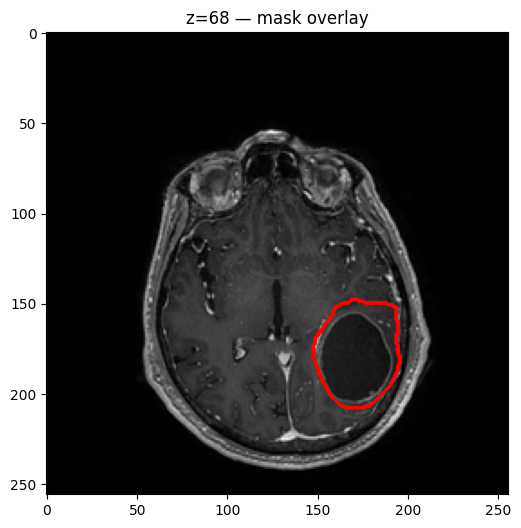

In [ ]:
mask  = session.target_buffer.clone().cpu().numpy().astype("uint8")
mr_np = sitk.GetArrayFromImage(input_image)
print("mask shape:", mask.shape, "| total tumour voxels:", int(mask.sum()))
print("voxels on slice", z_slice, ":", int(mask[z_slice].sum()))

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(mr_np[z_slice], cmap='gray')
if mask[z_slice].sum() > 0:
    ax.contour(mask[z_slice], colors='r')
ax.set_title(f'z={z_slice} — mask overlay')
plt.show()

### Tumor Mask Export

In [ ]:
mask_img = sitk.GetImageFromArray(mask)
mask_img.CopyInformation(input_image)
sitk.WriteImage(mask_img, "tumor_mask.nii.gz")
files.download("tumor_mask.nii.gz")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>